# Precomputed $p(m_r|z,population) dm_r$ distribution functions modelled through `GALFRB`.

Before executing the following script ensure that the file `'p_mr_distributions_dz0.01_z_in_0_1.2.h5'` is located in the same directory level. If it is stored elsewhere, specify the correct directory path via the variable `output_dir = <path_to_file>` in `load_p_mr_distributions()`.

In [1]:
#Libraries
import numpy as np
import matplotlib.pyplot as plt
import h5py
import seaborn as sns

#plt.style.use("nick_style")

### Load the distributions

In [2]:
def load_p_mr_distributions(fname: str = 'p_mr_distributions_dz0.01_z_in_0_1.2.h5', output_dir: str = 'p_mr_dists/') -> tuple:
    """
    Load the p(mr|z) distributions from an HDF5 file.
    Args:
        fname (str): Input filename.
        output_dir (str): Directory where the file is stored.
    Returns:
        zbins (np.array): Redshift bin edges.
        rmag_centers (np.array): Centers of r-band magnitude bins.
        p_mr_sfr (np.array): p(mr|z) for SFR-weighted population. Shape: (len(zbins) - 1, rmag_resolution). rmag_resolution(=len(rmag_centers)) is fixed across redshift bins.
        p_mr_mass (np.array): p(mr|z) for Mass-weighted population. Shape: (len(zbins) - 1, rmag_resolution). rmag_resolution(=len(rmag_centers)) is fixed across redshift bins.
    Note:
        The PDF in m_r within a given redshift bin [z1,z2] has been computed at the right edge of the bin (z = z2).
    """

    with h5py.File(output_dir + fname, 'r') as hf:
        zbins = np.array(hf['zbins'])
        rmag_centers = np.array(hf['rmag_centers'])
        p_mr_sfr = np.array(hf['p_mr_sfr'])
        p_mr_mass = np.array(hf['p_mr_mass'])

    print(f"p(mr|z) distributions loaded successfully from 'p_mr_dists/{fname}'")
    n_redshift_bins = len(zbins) - 1

    def give_p_mr_mass(z: float):
        """
        Function to return p(mr|z) for mass-weighted population.
        Args:
            z (float): Redshift value.
        Returns:
            np.array: p(mr|z) values.
        Note:
            This function assumes that the redshift bins are defined in the `massweighted_population` data.
            Given the fine discretization of redshift bins, it uses the nearest bin for the provided redshift value.
            rmag_centers and p_mr_mass are defined in the outer scope of this function.
        """
        # Find the appropriate redshift bin index
        idx = np.clip(np.searchsorted(zbins, z) - 1, 0,  n_redshift_bins - 1)
        return p_mr_mass[idx]
    
    def give_p_mr_sfr(z: float):
        """
        Function to return p(mr|z) for SFR-weighted population.
        Args:
            z (float): Redshift value.
        Returns:
            np.array: p(mr|z) values.
        Note:
            This function assumes that the redshift bins are defined in the `sfrweighted_population` data.
            Given the fine discretization of redshift bins, it uses the nearest bin for the provided redshift value.
            rmag_centers and p_mr_sfr are defined in the outer scope of this function.
        """
        # Find the appropriate redshift bin index
        idx = np.clip(np.searchsorted(zbins, z) - 1, 0,  n_redshift_bins - 1)
        return p_mr_sfr[idx]

    return zbins, rmag_centers, p_mr_sfr, p_mr_mass, give_p_mr_sfr, give_p_mr_mass

In [3]:
zbins, rmag_centers, p_mr_sfr, p_mr_mass, give_p_mr_sfr, give_p_mr_mass = load_p_mr_distributions(fname = 'p_mr_distributions_dz0.01_z_in_0_1.2.h5', output_dir = 'p_mr_dists/')

p(mr|z) distributions loaded successfully from 'p_mr_dists/p_mr_distributions_dz0.01_z_in_0_1.2.h5'


### Integrate the precomputed PDFs into **PATH** and perform standard FRB host-association analysis

This section demonstrates how to make use of the precomputed probability density functions (PDFs)  
\( p(m_r \mid z, \text{population}) \), which shall be implemented into the **PATH** algorithm.


##### **Usage**

To retrieve the PDF for a given galaxy redshift and a given population:

```
give_p_mr_<population>(z=<z_of_galaxy>)
```

##### **Arguments**

- z : galaxy redshift
- population : galaxy population (i.e., `SFR` or `mass`) 

##### **Returns**

An 1D array representing
$$p(m_r | z_{gal}, \text{population})$$
evaluated on the predefined `rmag_centers` magnitude grid

##### Notes

- PDFs are normalized such that $$\int p(m_r | z, \text{population}) ~dm_r =1 \implies \sum_i p_i \Delta m_{r} = 1$$ where $\Delta m_r$ is the `rmag_centers` bin width.

- The precomputed PDFs for a given `population` lie on a redshift-rmag grid described by `zbins - rmag_centers` .

- GALFRB data were obtained assuming `space_dist = 'delta_at_zright'`, i.e., all galaxies lie on the upper z bound at a given redshift bin $[z_1,z_2]$ with a fine redshift resolution of $\Delta z = 0.01$ within $[0,1.2]$. 

**Example usage**

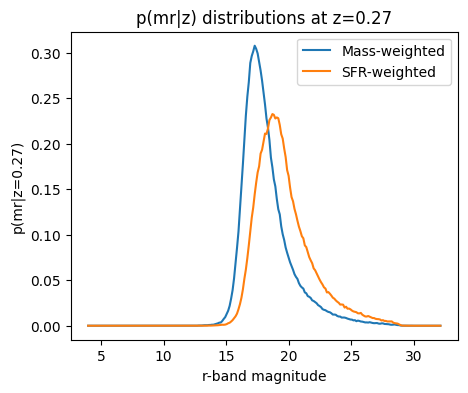

In [4]:
plt.figure(figsize=(5,4))
plt.plot(rmag_centers, give_p_mr_mass(z=0.27), label='Mass-weighted')
plt.plot(rmag_centers, give_p_mr_sfr(z=0.27), label='SFR-weighted')
plt.xlabel('r-band magnitude')
plt.ylabel('p(mr|z=0.27)')
plt.title('p(mr|z) distributions at z=0.27')
plt.legend()
plt.show()

**Plot slices of all the precomputed PDFs**

Plotting p(mr|z) distributions from stored file...
Plotting for z in [0.0, 0.01]...
Plotting for z in [0.01, 0.02]...
Plotting for z in [0.02, 0.03]...
Plotting for z in [0.03, 0.04]...
Plotting for z in [0.04, 0.05]...
Plotting for z in [0.05, 0.06]...
Plotting for z in [0.06, 0.07]...
Plotting for z in [0.07, 0.08]...
Plotting for z in [0.08, 0.09]...
Plotting for z in [0.09, 0.1]...
Plotting for z in [0.1, 0.11]...
Plotting for z in [0.11, 0.12]...
Plotting for z in [0.12, 0.13]...
Plotting for z in [0.13, 0.14]...
Plotting for z in [0.14, 0.15]...
Plotting for z in [0.15, 0.16]...
Plotting for z in [0.16, 0.17]...
Plotting for z in [0.17, 0.18]...
Plotting for z in [0.18, 0.19]...
Plotting for z in [0.19, 0.2]...
Plotting for z in [0.2, 0.21]...
Plotting for z in [0.21, 0.22]...
Plotting for z in [0.22, 0.23]...
Plotting for z in [0.23, 0.24]...
Plotting for z in [0.24, 0.25]...
Plotting for z in [0.25, 0.26]...
Plotting for z in [0.26, 0.27]...
Plotting for z in [0.27, 0.28]...
Pl

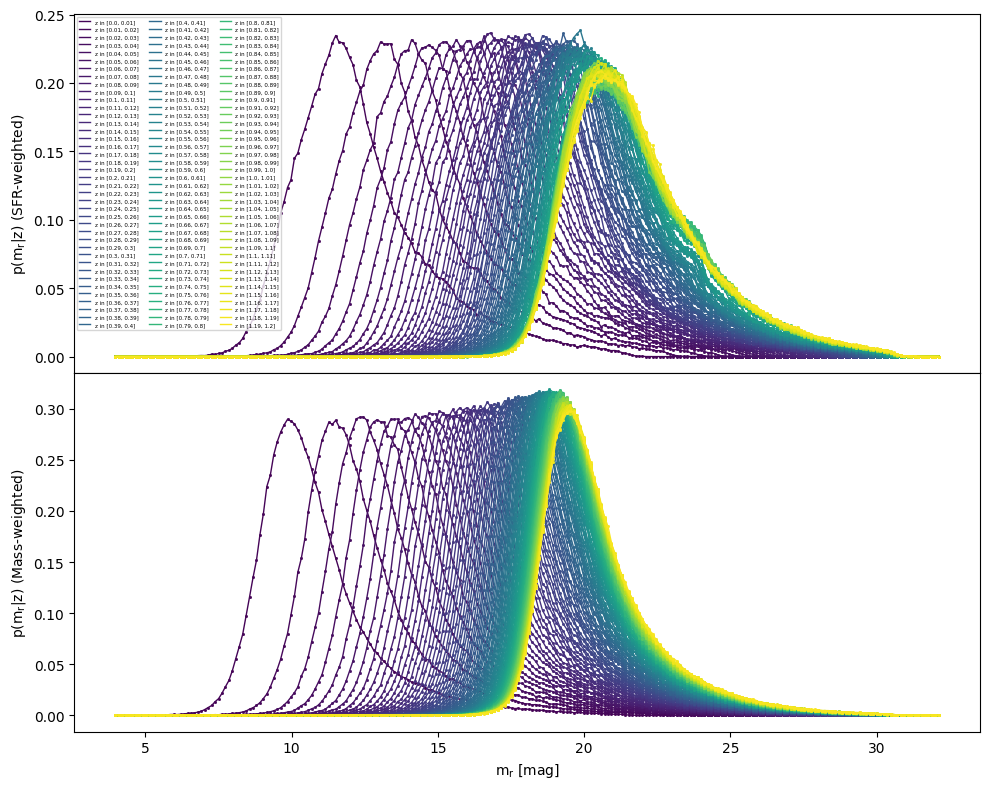

In [5]:
def test_():

    #zbins, rmag_centers, give_p_mr_sfr, give_p_mr_mass = load_p_mr_distributions(fname = 'p_mr_distributions_dz0.01_z_in_0_1.2.h5', output_dir = 'p_mr_dists/')

    plt.subplots(2,1, figsize=(10,8), sharex=True, gridspec_kw={'wspace': 0, 'hspace': 0})
    clrs = sns.color_palette("viridis", len(zbins)-1)
    print('Plotting p(mr|z) distributions from stored file...')
    for i in range(len(zbins)-1):
        print(f'Plotting for z in [{zbins[i]}, {zbins[i+1]}]...', flush=True)
        plt.subplot(2,1,1)
        plt.plot(rmag_centers, p_mr_sfr[i], color = clrs[i], lw=1, ls='-', marker='', label=f'z in [{zbins[i]}, {zbins[i+1]}]')
        plt.plot(rmag_centers, give_p_mr_sfr(z=0.5*(zbins[i]+zbins[i+1])), color = clrs[i], lw=1, ms=1, ls='', marker='s')

        plt.subplot(2,1,2)
        plt.plot(rmag_centers, p_mr_mass[i], color = clrs[i], lw=1, ls='-', marker='', label=f'z in [{zbins[i]}, {zbins[i+1]}]')
        plt.plot(rmag_centers, give_p_mr_mass(z=0.5*(zbins[i]+zbins[i+1])), color = clrs[i], lw=1, ms=1, ls='', marker='s')

    plt.xlabel(r'$\rm{m_r}$ [mag]')
    plt.subplot(2,1,1)
    plt.ylabel(r'$\rm{p(m_r|z)}$ (SFR-weighted)')
    plt.legend(fontsize=4, ncol=3)
    plt.subplot(2,1,2)
    plt.ylabel(r'$\rm{p(m_r|z)}$ (Mass-weighted)')
    #plt.legend()
    plt.tight_layout()
    plt.show()
    return

test_()


In [6]:
#EOF